<h2 style="text-align:center;"> HELLENIC OPEN UNIVERSITY - SCHOOL OF SCIENCE AND TECHNOLOGY</h2>
<h2 style="text-align:center;"> DATA SCIENCE AND MACHINE LEARNING : DAMA61 ACAD. YEAR 2025-26</h2>

<h3 style="text-align:center;"> WRITTEN ASSIGNMENT 5 - Solutions</h3>

<hr>

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

### Problem 1:

In this problem, you will apply a Convolutional Neural Network (CNN) for image classification using the CIFAR-10 dataset, and you will evaluate the training process of an Adam and an SGD optimizer. </br>
<i>Note: Use 42 as the random seed value wherever possible and use accuracy as the metric for training the CNNs.</i>

1) Load the CIFAR-10 dataset using Keras, normalize all pixel values to the range [0,1], then shuffle and split the full dataset (60,000 images) into three subsets: 60% training, 20% validation, and 20% test. Print the shapes of all three splits. [10%]

2) Convert the target values into one-hot vectors. [5%]

3) Built a convolutional neural network (CNN). For the features extractor part of the CNN, create:
- a 2D convolutional layer of 16, 5x5 kernels, add padding zeros to the image and move each kernel two pixels,
- a 2D convolutional layer of 32, 3x3 kernels that retain the size of its input image and
- a 2D convolutional layer of 64, 3x3 kernels that retain the size of its input image.</br>
Each convolutional layer is followed by a 2x2 max pooling layer.

For the classification part of your model, start with a 25% dropout layer, then add two fully connected layers with 64 and 32 nodes, followed by the output layer. [40%]

4) Create a clone model of the above CNN with exactly the same initial weights. [5%]

5) Compile one model using the Adam optimizer and a loss function of your choice, and the other one with the SGD optimizer. Fit each model on the training data (allow 100 epochs) and use early stopping with patience of 5 epochs to monitor the validation set. [20%]

6) Plot the history of the loss and accuracy for each model during training, both on the training and validation sets. Comment on your results. [10%]

7) For the best performing model, plot its confusion matrix and its accuracy on the test set. [10%]

<i>Feel free to take any extra action to solve this problem.</i>

In [2]:
# import the needed packages
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D, Flatten, Dropout, Dense

### Question 1

In [3]:
from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

print("Original training set shape:", x_train_full.shape, y_train_full.shape)
print("Original test set shape:    ", x_test.shape, y_test.shape)

# Normalize the pixel values to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Original training set shape: (50000, 32, 32, 3) (50000, 1)
Original test set shape:     (10000, 32, 32, 3) (10000, 1)


In [4]:
# Combine train and test to split as 60/20/20
X = np.concatenate([x_train_full, x_test], axis=0)
Y = np.concatenate([y_train_full, y_test], axis=0)

print("Full dataset:", X.shape, Y.shape)

Full dataset: (60000, 32, 32, 3) (60000, 1)


In [5]:
np.random.seed(42)

# Shuffle the full dataset (for a proper random split)
indices = np.random.permutation(len(X))
X = X[indices]
Y = Y[indices]

# Split the full dateset to: 60% / 20% / 20%
n_total = len(X)  # 60000
n_train = int(0.6 * n_total)  # 36000
n_valid_and_test = int(0.2 * n_total)  # 12000

X_train = X[:n_train]
y_train = Y[:n_train]

X_valid = X[n_train:n_train + n_valid_and_test]
y_valid = Y[n_train:n_train + n_valid_and_test]

X_test = X[n_train + n_valid_and_test:]
y_test = Y[n_train + n_valid_and_test:]

# 6. Print shapes to verify
print("Training set:   ", X_train.shape, y_train.shape)
print("Validation set: ", X_valid.shape, y_valid.shape)
print("Test set:       ", X_test.shape, y_test.shape)

Training set:    (36000, 32, 32, 3) (36000, 1)
Validation set:  (12000, 32, 32, 3) (12000, 1)
Test set:        (12000, 32, 32, 3) (12000, 1)


### Question 2

In [6]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes = 10)
y_valid = tf.keras.utils.to_categorical(y_valid, num_classes = 10)
y_test  = tf.keras.utils.to_categorical(y_test,  num_classes = 10)

### Question 3

In [7]:
# fix the random numbers generators
def build_model():
    random.seed(42)
    np.random.seed(42)
    tf.random.set_seed(42)

    model = Sequential()
    model.add(InputLayer(shape=(32, 32, 3)))
    model.add(Conv2D(16, (5, 5), padding = 'same', strides = 2, activation = 'relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(32, (3, 3), padding = 'same', activation = 'relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), padding = 'same', activation = 'relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dropout(0.25))
    model.add(Dense(64, activation = 'relu'))
    model.add(Dense(32, activation = 'relu'))
    model.add(Dense(10, activation = 'softmax'))

    return model

### Question 4

In [8]:
# store the initial weights of the model
model = build_model()
model_init_weights = model.get_weights().copy()

### Question 5

In [9]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor = "val_loss",
                                                  patience = 5,
                                                  restore_best_weights = True)

models, history = {}, {}
for optimizer in ['adam', 'sgd']:

    print(f"\nRunning {optimizer} ...")

    models[optimizer] = build_model()
    # reset the weights to the initial weights
    models[optimizer].set_weights(model_init_weights)
    
    models[optimizer].compile(optimizer = optimizer,
                              loss = "categorical_crossentropy",
                              metrics = ["accuracy"])

    history[optimizer] = models[optimizer].fit(X_train, y_train, epochs = 100, batch_size = 32,
                                               validation_data = (X_valid, y_valid),
                                               callbacks = [early_stopping],
                                               verbose=1)


Running adam ...
Epoch 1/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2466 - loss: 1.9846 - val_accuracy: 0.4437 - val_loss: 1.4861
Epoch 2/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4520 - loss: 1.4887 - val_accuracy: 0.5031 - val_loss: 1.3578
Epoch 3/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5134 - loss: 1.3398 - val_accuracy: 0.5402 - val_loss: 1.2757
Epoch 4/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5552 - loss: 1.2399 - val_accuracy: 0.5667 - val_loss: 1.2033
Epoch 5/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5815 - loss: 1.1737 - val_accuracy: 0.5798 - val_loss: 1.1824
Epoch 6/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5990 - loss: 1.1129 - val_accuracy: 0.5924 - val_loss: 1.1582
Epoch 7/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6132 - loss: 1.0789 - val_accuracy: 0.6162 - val_loss: 1.1007
Epoch 8/100
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy

### Question 6

In [10]:
def plot_history(history, title):
    epoch_index = np.array(history.epoch) + 1

    fig, ax = plt.subplots(figsize = (8, 4))
    ax.set_title(title)
    ax.plot(epoch_index, history.history['loss'], "r-", label = "Train loss")
    ax.plot(epoch_index, history.history['val_loss'], "b-", label = "Validation loss")
    ax.set_ylabel("Loss (lines)")
    ax.set_xlabel("Epoch")
    ax.tick_params(axis='x', labelrotation=90)
    ax.grid()

    ax1 = ax.twinx()

    ax1.plot(epoch_index, history.history['accuracy'], "ro", label = "Train")
    ax1.plot(epoch_index, history.history['val_accuracy'], "bo", label = "Validation")
    ax1.set_ylabel("Accuracy (dots)")

    
    plt.xticks(epoch_index)
    plt.legend(loc = 'center right')
    plt.show()

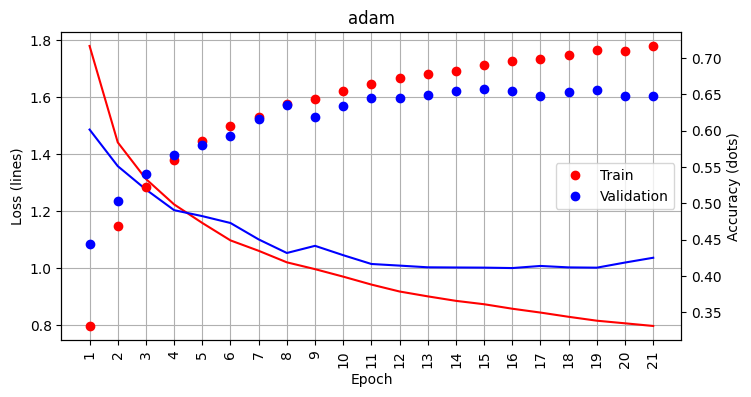

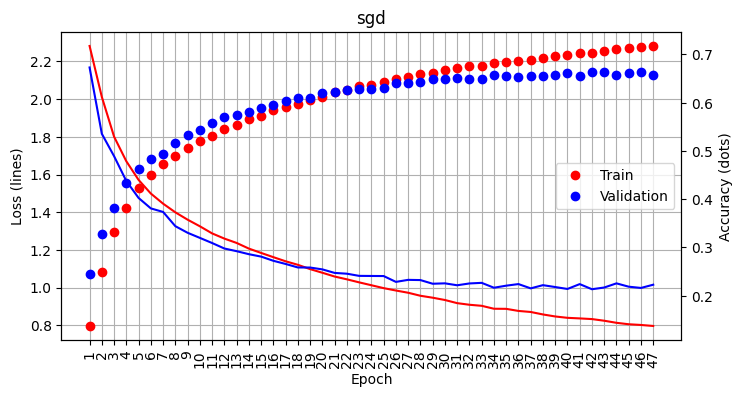

In [11]:
for optimizer in ['adam', 'sgd']:
    plot_history(history[optimizer], optimizer)

<b> Comment: </b> SGD trains more slowly but steadily, with training and validation loss and accuracy improving together. In contrast, Adam converges much faster at the start, but the growing gap between training and validation performance later on suggests increased overfitting. Overall, SGD tends to produce more stable and reliable generalization in this case.

### Question 7

In [12]:
best_optimizer = 'sgd'

In [13]:
test_loss, test_accuracy = models[best_optimizer].evaluate(X_test, y_test, verbose=0)
print(f"\n{best_optimizer} - The accuracy on the test set is: {test_accuracy:.1%}")


sgd - The accuracy on the test set is: 65.3%


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


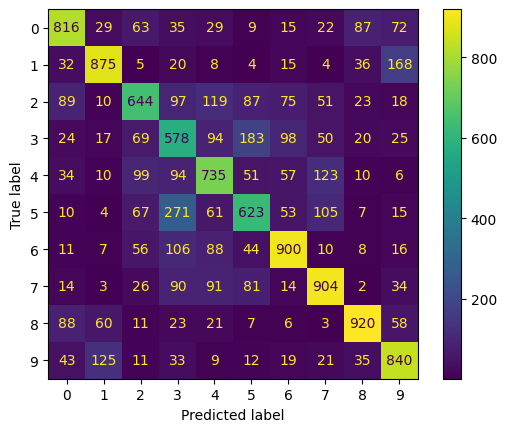

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(np.argmax(y_test, axis = 1), np.argmax(models[best_optimizer].predict(X_test), axis = 1))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

<hr>

## Problem 2

In this assignment, you will build and evaluate deep learning models for multi-step time series forecasting using a real-world dataset of daily temperatures. Your goal is to design models that take as input a sequence of past observations and predict a sequence of future values. Specifically, given the previous 30 days of temperature data, you will forecast the next 7 days. The daily minimum temperatures spanning from 1981 to 1991 can be obtained from https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv. 

1) Load, inspect, print descriptive statistics and plot the entire dataset. [5%]

2) Split the dataset into training (70%), validation (15%) and testing (15%) and standardize the corresponding splits. It should be noted that for all questions we will use the scaled data. [5%]

3) Design a function that will create the necessary windows (training and targets) for the three splits. Visualize the first training sample and its corresponding target. [15%]

4) Build a Simple RNN with 3 hidden layers and 32 Neurons for each hidden layer. Add also the required output layer in order to forecast 7 days in the future at and return the result into the proper format (sequence to vector), using 30 previous days. Train the RNN with Adam, Huber loss function and early stopping with patience steps equal to 5. After training plot Loss and MAE for training and validation dataset. Use the model to predict using the test data and plot the corresponding inputs and targets along with the predictions for the first six samples of the test set. Compute MAE and RMSE over all predictions in the test set. [30%]

5) By reshaping the data appropriatelly prepare the three splits for sequence to sequence forecasting with the same number of previous days and days ahead. Utilize batches of 16 samples and avoid shuffling. The model to be used will consist of 3 Gated Recurrent Unit - based layers with 32 neurons each and appropriate output layer. Print the same results as Q4. Compare the two approaches and discuss the key points. [45%]

<i>Note: Set seed to 42 where appropriate. All metrics should be printed on the original scaling where possible.</i>


### Helpful imports and parameter setup

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

### Question 1

        Date  Temp
0 1981-01-01  20.7
1 1981-01-02  17.9
2 1981-01-03  18.8
3 1981-01-04  14.6
4 1981-01-05  15.8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3650 non-null   datetime64[ns]
 1   Temp    3650 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 57.2 KB
                      Date         Temp
count                 3650  3650.000000
mean   1985-12-31 07:12:00    11.177753
min    1981-01-01 00:00:00     0.000000
25%    1983-07-02 06:00:00     8.300000
50%    1985-12-31 12:00:00    11.000000
75%    1988-06-30 18:00:00    14.000000
max    1990-12-31 00:00:00    26.300000
std                    NaN     4.071837


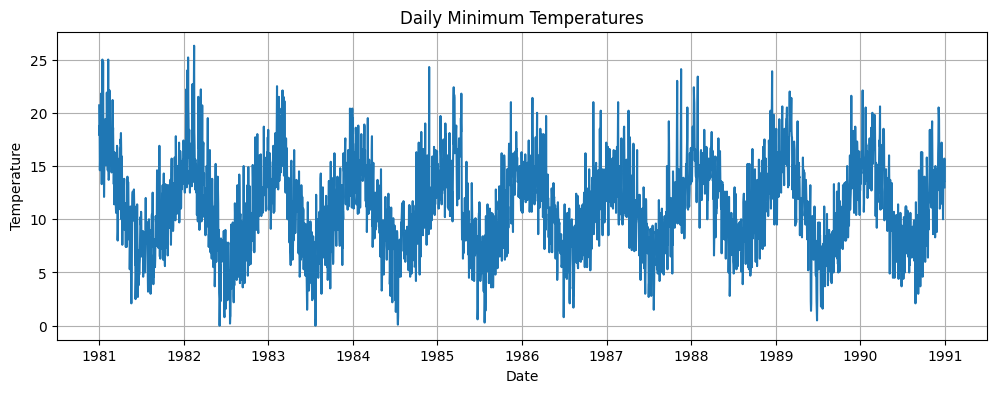

In [16]:
# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"

df = pd.read_csv(url, parse_dates=["Date"])
print(df.head())

# Inspect the dataset
df.info()

# Print descriptive statistics
print(df.describe())

# Plot the dataset
plt.figure(figsize=(12, 4))
plt.plot(df["Date"], df["Temp"])
plt.title("Daily Minimum Temperatures")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

### Question 2

In [17]:
from sklearn.preprocessing import StandardScaler

# Extract the values
values = df["Temp"].values.astype(np.float32)

# Split into training validation and testing
n = len(values)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

train_series = values[:train_end]
valid_series = values[train_end:valid_end]
test_series = values[valid_end:]

# Print the length of the datasets to check
print("Number of training samples   : ",len(train_series))
print("Number of validation samples : ",len(valid_series))
print("Number of testing samples    : ",len(test_series))

# Scale the data
scaler = StandardScaler()

# Reshape is required for the scaler
train_series_reshaped = train_series.reshape(-1, 1)
scaler.fit(train_series_reshaped)

# Transform
train_series_scaled = scaler.transform(train_series.reshape(-1, 1)).flatten()
valid_series_scaled = scaler.transform(valid_series.reshape(-1, 1)).flatten()
test_series_scaled = scaler.transform(test_series.reshape(-1, 1)).flatten()

# Function to be used for inverse transformation
def inverse_transform(series, scaler):
    return scaler.inverse_transform(series.reshape(-1, 1)).reshape(series.shape)

Number of training samples   :  2555
Number of validation samples :  547
Number of testing samples    :  548


### Question 3

Shape of Training data   :  (2519, 30, 1) (2519, 7, 1)
Shape of Validation data :  (511, 30, 1) (511, 7, 1)
Shape of Testing data    :  (512, 30, 1) (512, 7, 1)


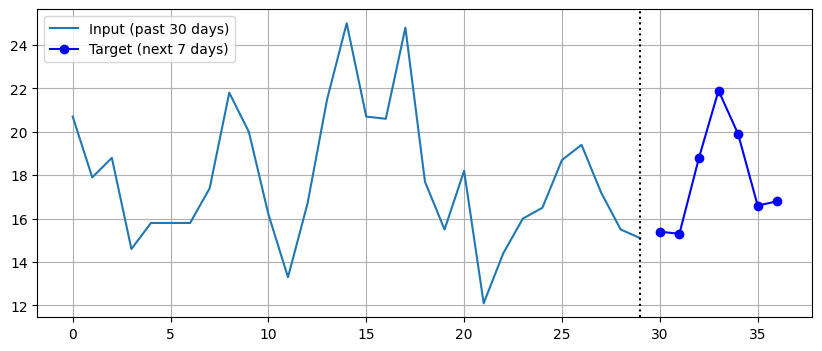

In [18]:
# Past and Future steps
past_steps = 30
future_steps = 7

# Function that makes windows of data to be used with the RNNs
def make_windows(series, past_steps, future_steps):
    X, Y = [], []
    for i in range(len(series) - past_steps - future_steps + 1):
        past = series[i:i + past_steps]
        future = series[i + past_steps:i + past_steps + future_steps]
        X.append(past)
        Y.append(future)
    X = np.array(X)[..., np.newaxis]
    Y = np.array(Y)[..., np.newaxis]
    return X, Y

# Make windows for all datasets
X_train, Y_train = make_windows(train_series_scaled, past_steps, future_steps)
X_valid, Y_valid = make_windows(valid_series_scaled, past_steps, future_steps)
X_test, Y_test = make_windows(test_series_scaled, past_steps, future_steps)

# Print the shapes to ensure they are conforming
print("Shape of Training data   : ", X_train.shape, Y_train.shape)
print("Shape of Validation data : ", X_valid.shape, Y_valid.shape)
print("Shape of Testing data    : ", X_test.shape, Y_test.shape)

# Visualize one training sample and its target
def plot_series(input_seq, target_seq=None, pred_seq=None):
    plt.figure(figsize=(10, 4))
    plt.plot(range(len(input_seq)), input_seq[:, 0], label="Input (past 30 days)")
    
    if target_seq is not None:
        plt.plot(
            range(len(input_seq), len(input_seq) + len(target_seq)),
            target_seq[:, 0],
            "bo-",
            label="Target (next 7 days)"
        )
    
    if pred_seq is not None:
        plt.plot(
            range(len(input_seq), len(input_seq) + len(pred_seq)),
            pred_seq[:, 0],
            "rx--",
            label="Prediction"
        )
    
    plt.axvline(len(input_seq) - 1, color="k", linestyle=":")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_series(inverse_transform(X_train[0],scaler), inverse_transform(Y_train[0],scaler))


### Question 4

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 30, 32)         │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 30, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           231 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,479 (21.40 KB)

 Trainable params: 5,479 (21.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2934 - mae: 0.6330 - val_loss: 0.2307 - val_mae: 0.5518
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2411 - mae: 0.5641 - val_loss: 0.2257 - val_mae: 0.5442
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2359 - mae: 0.5575 - val_loss: 0.2235 - val_mae: 0.5411
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2329 - mae: 0.5540 - val_loss: 0.2234 - val_mae: 0.5409
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2305 - mae: 0.5510 - val_loss: 0.2234 - val_mae: 0.5407
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2285 - mae: 0.5485 - val_loss: 0.2233 - val_mae: 0.5403
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2265 - mae: 0.5457 - val_loss: 0.2236 - val_mae: 0.5407
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2247 - mae: 0.5432 - val_loss: 0.2240 - val_mae: 0.5413
Epoch 9/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2229 - mae: 

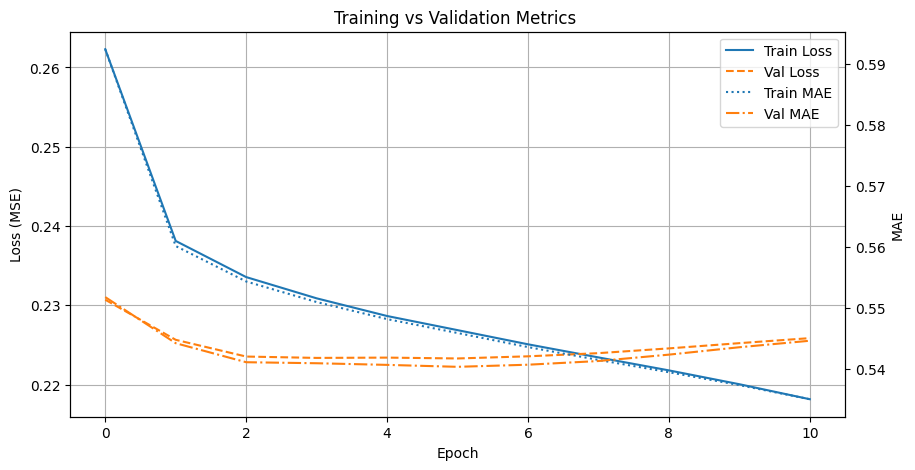

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Example 0


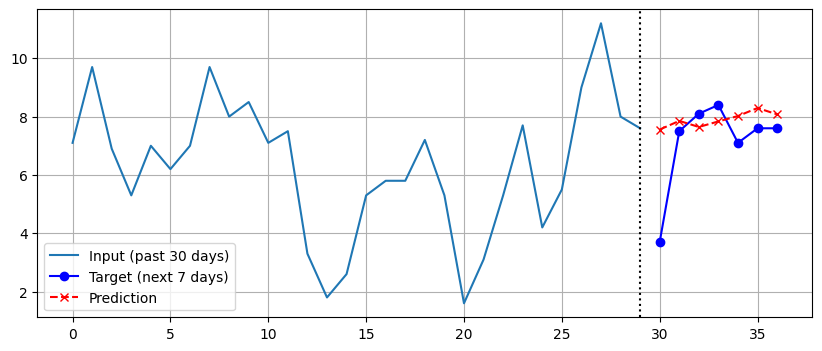

Example 1


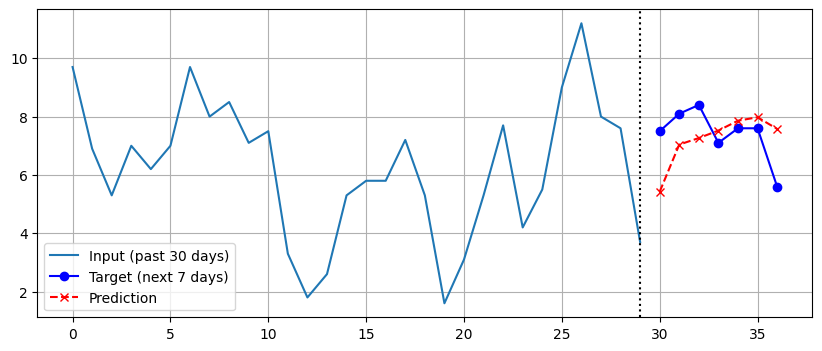

Example 2


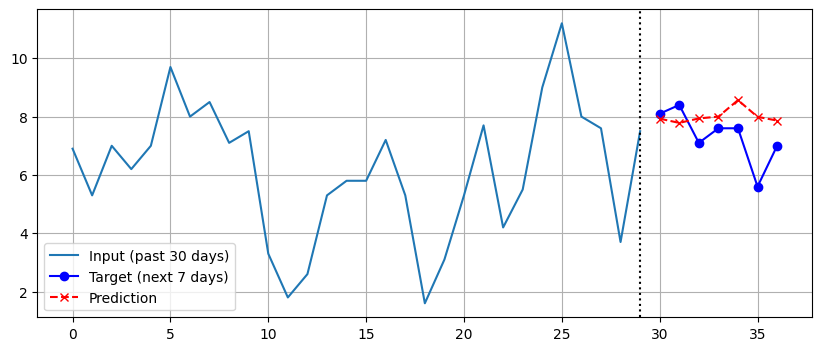

Example 3


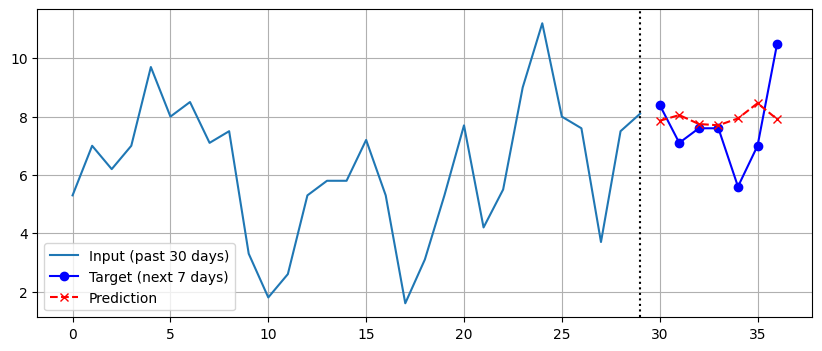

Example 4


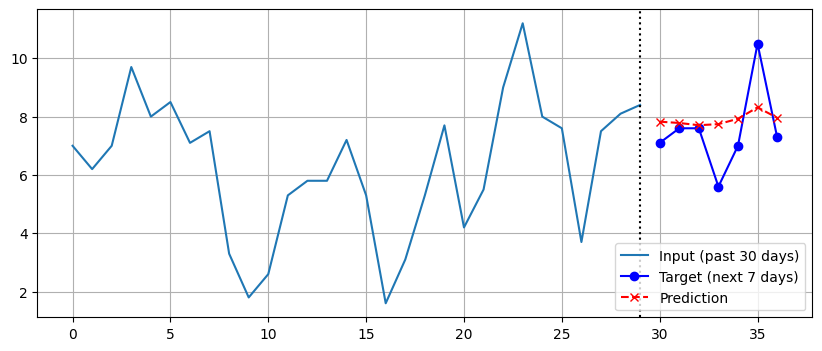

Example 5


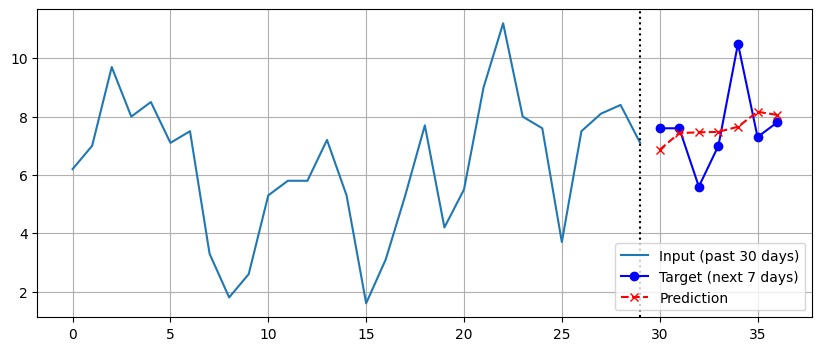

RNN MAE: 1.980674386024475
RNN RMSE: 2.5690321922302246


In [19]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Number of epochs
epochs = 30

# Create default RNN
model_rnn = keras.models.Sequential([
    keras.layers.Input(shape=[past_steps, 1]),
    keras.layers.SimpleRNN(32, return_sequences=True),
    keras.layers.SimpleRNN(32, return_sequences=True),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(future_steps),
    keras.layers.Reshape([future_steps, 1])
])

# Compile the model
model_rnn.compile(loss=tf.keras.losses.Huber(), optimizer="adam", metrics=["mae"])

# Summarize
model_rnn.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Train
history_rnn = model_rnn.fit(
    X_train, Y_train,
    epochs=epochs,
    validation_data=(X_valid, Y_valid),
    callbacks=[early_stopping],
    verbose=1
)

# Plot Loss and MAE for training and validation
fig, ax1 = plt.subplots(figsize=(10, 5))

# Loss (left axis)
ax1.plot(history_rnn.history["loss"], label="Train Loss")
ax1.plot(history_rnn.history["val_loss"], label="Val Loss", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (MSE)")
ax1.grid(True)

# MAE (right axis)
ax2 = ax1.twinx()
ax2.plot(history_rnn.history["mae"], label="Train MAE", linestyle=":")
ax2.plot(history_rnn.history["val_mae"], label="Val MAE", linestyle="-.")
ax2.set_ylabel("MAE")

# Title
plt.title("Training vs Validation Metrics ")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.show()

# Predict for the test set
Y_pred_rnn = model_rnn.predict(X_test)

# Plot the first six samples along with corresponding targets and predictions
for i in range(6):
    print(f"Example {i}")
    plot_series(
        inverse_transform(X_test[i],scaler),
        inverse_transform(Y_test[i],scaler),
        inverse_transform(Y_pred_rnn[i],scaler)
    )

# MAE and RMSE for RNN
mae_rnn = mean_absolute_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_rnn.reshape(-1),scaler)
)

rmse_rnn = root_mean_squared_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_rnn.reshape(-1),scaler)
)

# Print MAE and RMSE
print("RNN MAE:", mae_rnn)
print("RNN RMSE:", rmse_rnn)


### Question 5

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 32)         │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 30, 32)         │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 30, 7)          │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,263 (63.53 KB)

 Trainable params: 16,263 (63.53 KB)

 Non-trainable params: 0 (0.00 B)

...

158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2647 - mae: 0.5955 - val_loss: 0.2329 - val_mae: 0.5540
Epoch 6/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2637 - mae: 0.5941 - val_loss: 0.2323 - val_mae: 0.5530
Epoch 7/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2631 - mae: 0.5933 - val_loss: 0.2319 - val_mae: 0.5522
Epoch 8/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2626 - mae: 0.5925 - val_loss: 0.2315 - val_mae: 0.5515
Epoch 9/30
 17/158 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3243 - mae: 0.6701

2026-05-02 23:05:37.039718: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2621 - mae: 0.5919 - val_loss: 0.2311 - val_mae: 0.5510
Epoch 10/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2615 - mae: 0.5912 - val_loss: 0.2309 - val_mae: 0.5505
Epoch 11/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2610 - mae: 0.5905 - val_loss: 0.2306 - val_mae: 0.5500
Epoch 12/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2604 - mae: 0.5898 - val_loss: 0.2303 - val_mae: 0.5494
Epoch 13/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2596 - mae: 0.5889 - val_loss: 0.2300 - val_mae: 0.5486
Epoch 14/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2587 - mae: 0.5878 - val_loss: 0.2296 - val_mae: 0.5477
Epoch 15/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2577 - mae: 0.5866 - val_loss: 0.2290 - val_mae: 0.5465
Epoch 16/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2565 - mae: 0.5850 - val_loss: 0.2281 - val_mae: 0.5451
Epoch 17/30
 19/158 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - 

2026-05-02 23:05:49.304437: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2550 - mae: 0.5830 - val_loss: 0.2277 - val_mae: 0.5443
Epoch 18/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2535 - mae: 0.5812 - val_loss: 0.2277 - val_mae: 0.5441
Epoch 19/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2522 - mae: 0.5796 - val_loss: 0.2278 - val_mae: 0.5442
Epoch 20/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2509 - mae: 0.5780 - val_loss: 0.2279 - val_mae: 0.5445
Epoch 21/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2496 - mae: 0.5764 - val_loss: 0.2281 - val_mae: 0.5448
Epoch 22/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2483 - mae: 0.5749 - val_loss: 0.2283 - val_mae: 0.5452
Epoch 23/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.2470 - mae: 0.5735 - val_loss: 0.2284 - val_mae: 0.5456


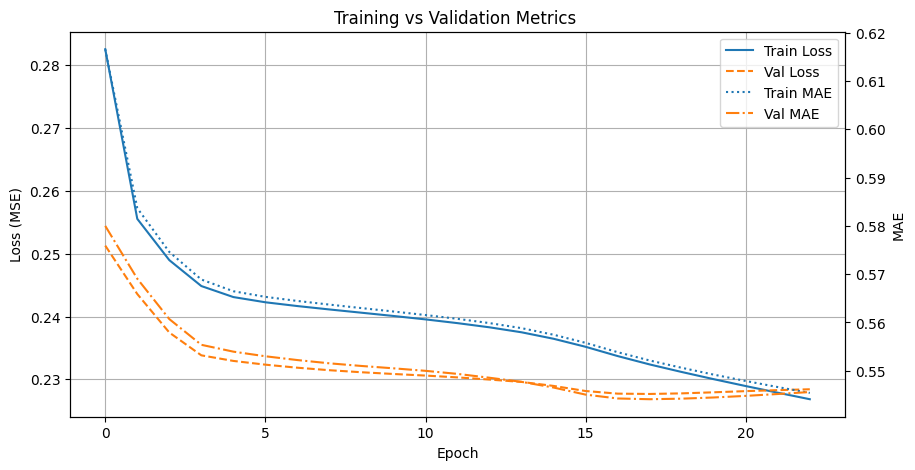

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
Example 0


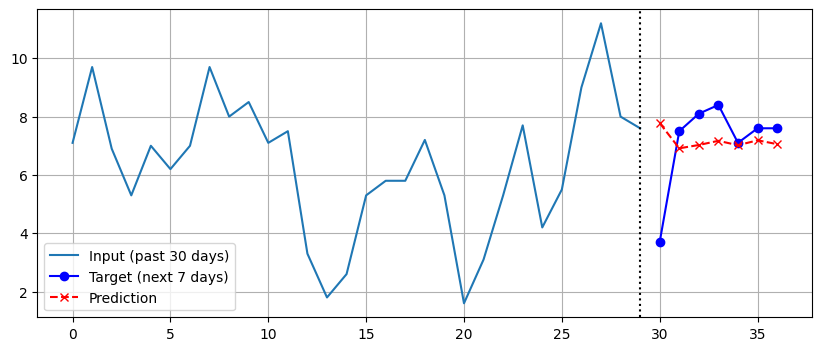

Example 1


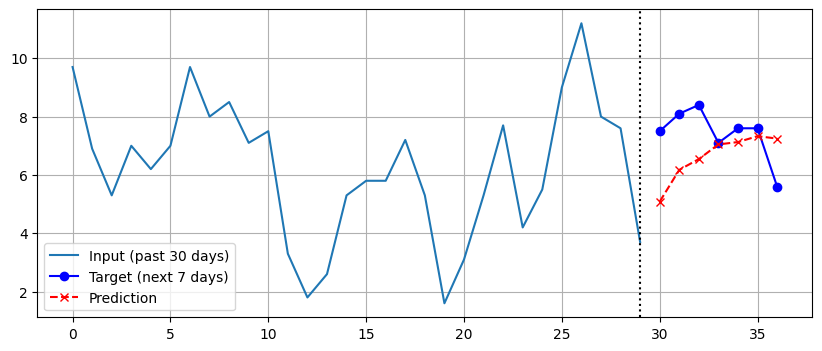

Example 2


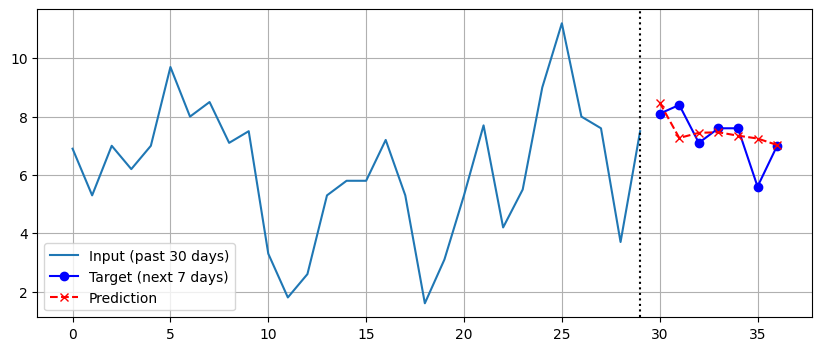

Example 3


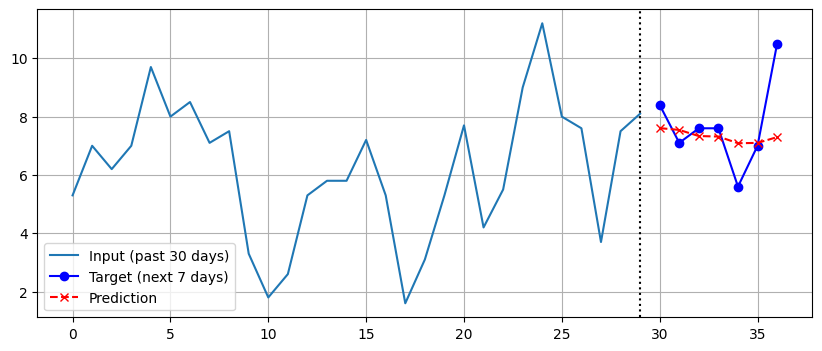

Example 4


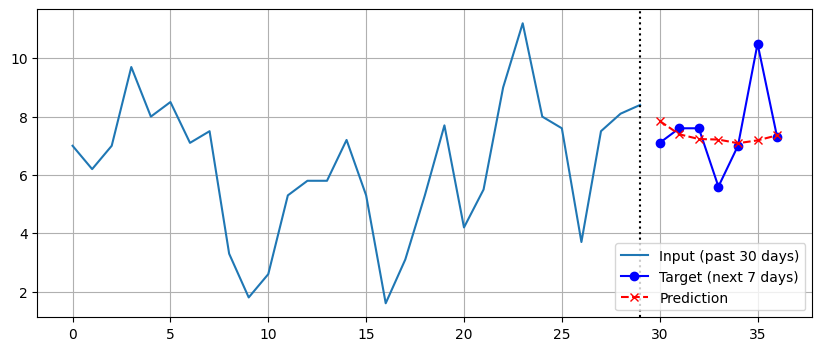

Example 5


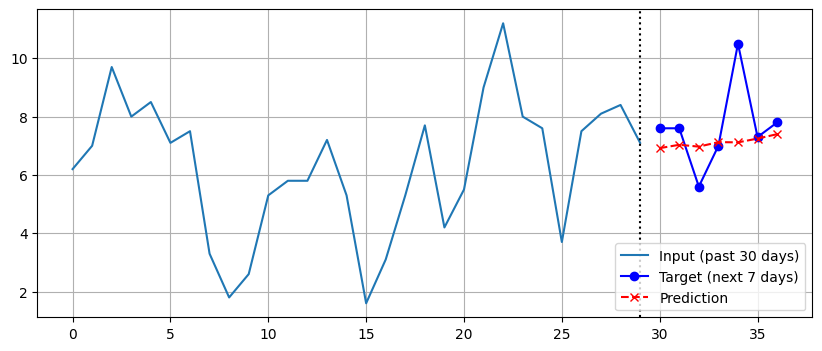

GRU MAE: 1.9725996255874634
GRU RMSE: 2.5499870777130127


In [20]:
# Function what creates windows
def to_windows(dataset, length):
    dataset = dataset.window(length, shift=1, drop_remainder=True)
    return dataset.flat_map(lambda window_ds: window_ds.batch(length))

# Function that creates the tensor form for training
def to_seq2seq_dataset(series, seq_length=past_steps, ahead=future_steps, target_col=0, batch_size=16, shuffle=False, seed=42):
    ds = to_windows(tf.data.Dataset.from_tensor_slices(series), ahead + 1)
    ds = to_windows(ds, seq_length).map(lambda S: (S[:, 0, :], S[:, 1:, target_col]))
    if shuffle:
        ds = ds.shuffle(8 * batch_size, seed=seed)
    return ds.batch(batch_size)

train_series_scaled_seq = to_seq2seq_dataset(train_series_scaled.reshape(-1, 1))
valid_series_scaled_seq = to_seq2seq_dataset(valid_series_scaled.reshape(-1, 1))
test_series_scaled_seq = to_seq2seq_dataset(test_series_scaled.reshape(-1, 1))

# Create default GRU
model_gru = keras.models.Sequential([
    keras.layers.Input(shape=[past_steps, 1]),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.GRU(32, return_sequences=True),
    keras.layers.Dense(future_steps)
])

# Compile the model
model_gru.compile(loss=tf.keras.losses.Huber(), optimizer="adam", metrics=["mae"])

# Summarize
model_gru.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

# Train
history_gru = model_gru.fit(
    train_series_scaled_seq,
    epochs=epochs,
    validation_data=valid_series_scaled_seq,
    callbacks=[early_stopping],
    verbose=1
)

# Plot Loss and MAE for training and validation
fig, ax1 = plt.subplots(figsize=(10, 5))

# Loss (left axis)
ax1.plot(history_gru.history["loss"], label="Train Loss")
ax1.plot(history_gru.history["val_loss"], label="Val Loss", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (MSE)")
ax1.grid(True)

# MAE (right axis)
ax2 = ax1.twinx()
ax2.plot(history_gru.history["mae"], label="Train MAE", linestyle=":")
ax2.plot(history_gru.history["val_mae"], label="Val MAE", linestyle="-.")
ax2.set_ylabel("MAE")

# Title
plt.title("Training vs Validation Metrics ")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.show()

# Predict for the test set
Y_pred_gru = model_gru.predict(X_test)

# Keep only the prediction at the last input time step
Y_pred_gru = Y_pred_gru[:, -1, :]          # shape: (n_samples, future_steps)

# Reshape to match Y_test: (n_samples, future_steps, 1)
Y_pred_gru = Y_pred_gru[..., np.newaxis]

# Plot the first six samples along with corresponding targets and predictions
for i in range(6):
    print(f"Example {i}")
    plot_series(
        inverse_transform(X_test[i],scaler),
        inverse_transform(Y_test[i],scaler),
        inverse_transform(Y_pred_gru[i],scaler)
    )

# MAE and RMSE for RNN
mae_gru = mean_absolute_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_gru.reshape(-1),scaler)
)

rmse_gru = root_mean_squared_error(
    inverse_transform(Y_test.reshape(-1),scaler),
    inverse_transform(Y_pred_gru.reshape(-1),scaler)
)

# Print MAE and RMSE
print("GRU MAE:", mae_gru)
print("GRU RMSE:", rmse_gru)

The GRU model shows a consistent but modest improvement over the SimpleRNN. From the learning curves, both models converge smoothly, but the RNN begins to exhibit slight overfitting after a few epochs, as its training loss continues to decrease while the validation loss flattens and slightly increases. In contrast, the GRU maintains closer alignment between training and validation curves, indicating better generalization. This is reflected in the quantitative metrics: the GRU achieves lower MAE and RMSE , suggesting more accurate and stable multi-step forecasts. Overall, the results confirm the expected advantage of GRUs over vanilla RNNs, as their gating mechanism allows them to capture temporal dependencies more effectively and reduces issues such as vanishing gradients. However, the GRU requires significantly more training time for training, since it is a more complex model in terms of units.